In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import statsmodels.formula.api as smf

In [2]:
# Load data
rev = pd.read_csv('data/revenue.csv')
spend = pd.read_csv('data/spend.csv')

In [3]:
# df overview
rev.head(5)

,date,city,region,revenue_sek,transactions
0,2025-01-01,Boras,Vastra Gotaland,66866.93,99
1,2025-01-01,Eskilstuna,Sodermanland,64413.53,98
2,2025-01-01,Gavle,Gavleborg,69744.08,104
3,2025-01-01,Goteborg,Vastra Gotaland,232221.00,307
4,2025-01-01,Halmstad,Halland,56329.08,85


In [4]:
# df overview
spend.head(5)

,date,city,region,campaign,adset,spend_sek
0,2025-01-01,Boras,Vastra Gotaland,Brand Search,Brand | Broad Match,940.85
1,2025-01-01,Boras,Vastra Gotaland,Brand Search,Brand | Exact Match,1298.16
2,2025-01-01,Boras,Vastra Gotaland,Generic Search,Generic | Fashion,1852.20
3,2025-01-01,Boras,Vastra Gotaland,Generic Search,Generic | Shoes & Accessories,1200.98
4,2025-01-01,Eskilstuna,Sodermanland,Brand Search,Brand | Broad Match,1062.09


## EDA

In [5]:
#checking for NAs
rev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4760 entries, 0 to 4759
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          4760 non-null   object 
 1   city          4760 non-null   object 
 2   region        4760 non-null   object 
 3   revenue_sek   4760 non-null   float64
 4   transactions  4760 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 186.1+ KB


In [6]:
#checking for NAs
spend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21224 entries, 0 to 21223
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       21224 non-null  object 
 1   city       21224 non-null  object 
 2   region     21224 non-null  object 
 3   campaign   21224 non-null  object 
 4   adset      21224 non-null  object 
 5   spend_sek  21224 non-null  float64
dtypes: float64(1), object(5)
memory usage: 995.0+ KB


In [7]:
# Fix dates
rev['date'] = pd.to_datetime(rev['date'], format='%Y-%m-%d')
spend['date'] = pd.to_datetime(spend['date'], format='%Y-%m-%d')

In [8]:
# Define the groups
treatment_cities = ['Goteborg', 'Uppsala', 'Vasteras', 'Orebro', 'Linkoping', 'Karlstad', 'Jonkoping', 'Sundsvall', 'Umea', 'Gavle']
control_cities = ['Kungsbacka', 'Malmo', 'Lund', 'Helsingborg', 'Boras', 'Eskilstuna', 'Norrkoping', 'Halmstad', 'Vaxjo', 'Trollhattan']

In [9]:
# Add a 'group' column
rev['group'] = rev['city'].apply(lambda x: 'Treatment' if x in treatment_cities else 'Control')

## Group comparability
- Checking if the Treatment and Control cities were actually behaving the same way before the test started in July. If they weren't, the "negative result" might just be because the groups were never comparable.

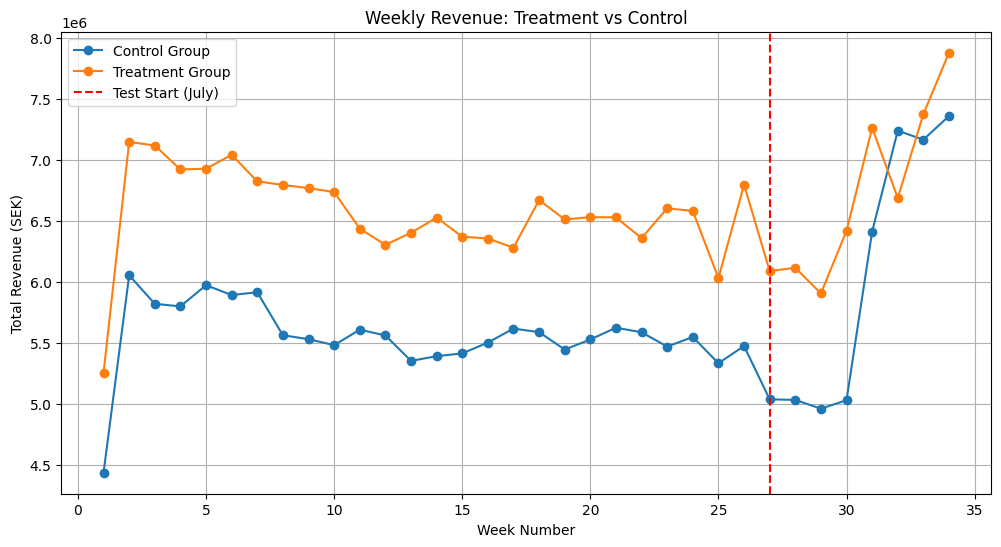

In [10]:
# 1. Create a Week column
rev['week'] = rev['date'].dt.isocalendar().week

# Remove the incomplete Week 35
rev = rev[rev['week'] < 35]

# 2. Group by Week and Group (Treatment vs Control)
weekly_rev = rev.groupby(['week', 'group'])['revenue_sek'].sum().reset_index()

# 3. Pivot the data for plotting
pivot_rev = weekly_rev.pivot(index='week', columns='group', values='revenue_sek')

# 4. Plot it!
plt.figure(figsize=(12, 6))
plt.plot(pivot_rev.index, pivot_rev['Control'], label='Control Group', marker='o')
plt.plot(pivot_rev.index, pivot_rev['Treatment'], label='Treatment Group', marker='o')

# Add a vertical line for when the test started (Week 27)
plt.axvline(x=27, color='red', linestyle='--', label='Test Start (July)')

plt.title('Weekly Revenue: Treatment vs Control')
plt.ylabel('Total Revenue (SEK)')
plt.xlabel('Week Number')
plt.legend()
plt.grid(True)
plt.show()

- Because the blue line and the orange line move in the exact same pattern (the peaks and valleys match up perfectly) before the red line at Week 27, we can confidently say that these two groups of cities are highly comparable. The Control group is a good baseline.

- The Control group had higher growth (or a better trend) during the test period.

## AOV analysis
- checks whether the groups differ in purchase behaviour, not just total revenue

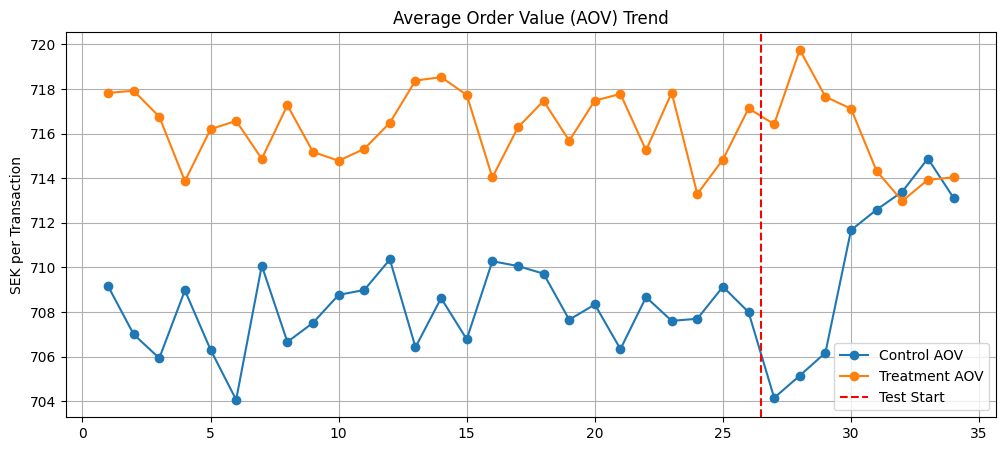

In [11]:
# 1. Group by Week and Group to get both Revenue and Transactions
weekly_stats = rev.groupby(['week', 'group']).agg(
    total_rev=('revenue_sek', 'sum'),
    total_trans=('transactions', 'sum')
).reset_index()

# 2. Calculate AOV
weekly_stats['aov'] = weekly_stats['total_rev'] / weekly_stats['total_trans']

# 3. Pivot for plotting
pivot_aov = weekly_stats.pivot(index='week', columns='group', values='aov')

# 4. Plot AOV Trends
plt.figure(figsize=(12, 5))
plt.plot(pivot_aov.index, pivot_aov['Control'], label='Control AOV', marker='o')
plt.plot(pivot_aov.index, pivot_aov['Treatment'], label='Treatment AOV', marker='o')
plt.axvline(x=26.5, color='red', linestyle='--', label='Test Start')
plt.title('Average Order Value (AOV) Trend')
plt.ylabel('SEK per Transaction')
plt.legend()
plt.grid(True)
plt.show()

- During the baseline (Weeks 1-26), both groups are stable and move in parallel.
- Then after Week 27 something notable happens: Treatment AOV dips sharply right at test start, while Control AOV rises and the two lines converge by Weeks 32-34.
- The Sale in Control cities likely drove higher-value purchases (people buying more during a promotion), inflating both Control revenue and Control AOV. Meanwhile the Drive to Store campaign may be attracting foot traffic that skews toward smaller basket sizes initially.
- the control group was contaminated, not just more revenue, but structurally different buying behavior during the test. The sale changed how much customers spent per visit, making the comparison even less fair.

## Marketing Budget
- Checking to see if the 'Drive to Store' campaign  steals budget or clicks away from the existing campaigns (such as 'Brand Search' or 'Generic Search')

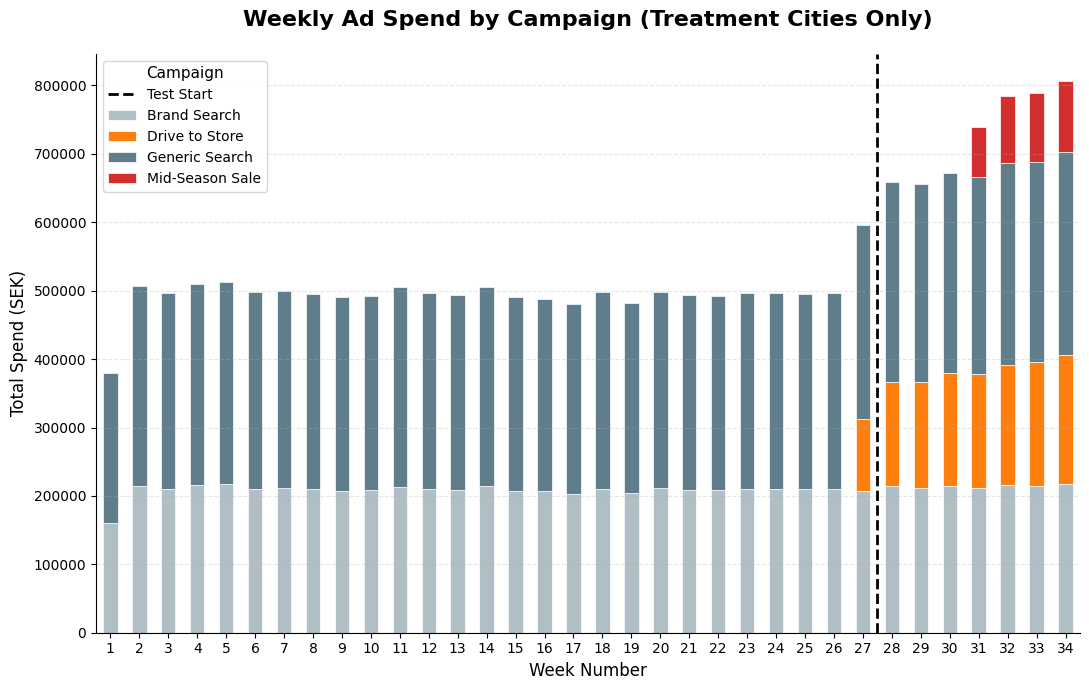

In [12]:
# 1. Map the 'group' label to the spend dataset
spend['group'] = spend['city'].apply(lambda x: 'Treatment' if x in treatment_cities else 'Control')

# 2. Add the week column to spend
spend['week'] = spend['date'].dt.isocalendar().week

# Remove the incomplete Week 35 from both datasets
spend = spend[spend['week'] < 35]

# 3. Filter for ONLY the Treatment cities (since Control didn't get the new ads)
treat_spend = spend[spend['group'] == 'Treatment']

# 4. Group by Week and Campaign, then pivot for a stacked bar chart
weekly_spend = treat_spend.groupby(['week', 'campaign'])['spend_sek'].sum().unstack().fillna(0)

# This ensures "Drive to Store" matches your "Treatment" orange from other slides
color_map = {
    'Brand Search': '#b0bec5',      # Neutral Gray
    'Drive to Store': '#ff7f0e',    # Treatment Orange (Matches your other charts)
    'Generic Search': '#607d8b',    # Slate Blue/Gray
    'Mid-Season Sale': '#d32f2f'    # Alert Red (Highlights the "anomaly")
}

# Ensure the colors are applied in the correct order of the columns
colors = [color_map.get(col, '#333333') for col in weekly_spend.columns]

# 5. Plot the stacked bar chart with the custom colors
ax = weekly_spend.plot(kind='bar', stacked=True, figsize=(11, 7), color=colors, edgecolor='white', linewidth=0.5)

plt.title('Weekly Ad Spend by Campaign (Treatment Cities Only)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Total Spend (SEK)', fontsize=12)
plt.xlabel('Week Number', fontsize=12)

# Add a vertical line for when the test started (Week 27)
plt.axvline(x=26.5, color='black', linestyle='--', linewidth=2, label='Test Start')

# Professional formatting
plt.legend(title='Campaign', loc='upper left', frameon=True, fontsize=10, title_fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0) # Keeps week numbers horizontal
sns.despine()
plt.tight_layout()
plt.show()

- Looks like there is no cannibalization of the search budget. The budget for the "Drive to Store" campaign seems to be net-new .

- The 'Mid Season Sale' can be a noise in the data that ruins tests. If a promotional sale happens right in the middle of the geo-lift test, it makes it incredibly hard to tell if people are walking into the store because of your "Drive to Store" ads, or just because there's a big sale.

## "Mid Season Sale" Hypothesis
- Trying to see how money moved for the "Mid Season Sale" ads in the Control cities versus the Treatment cities.

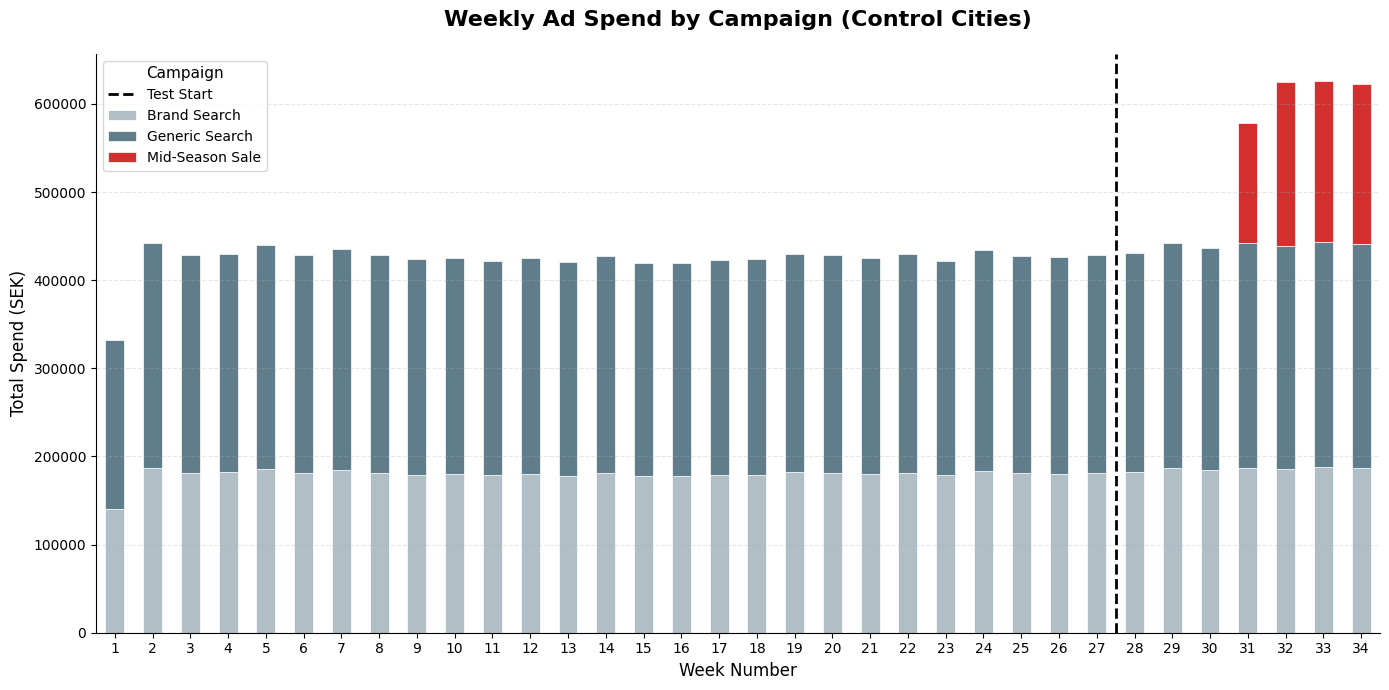

In [13]:
# 1. Filter for ONLY the Control cities
control_spend = spend[spend['group'] == 'Control']

# 2. Group by Week and Campaign, then pivot
weekly_spend_control = control_spend.groupby(['week', 'campaign'])['spend_sek'].sum().unstack().fillna(0)

# 3. Color Palette for consistency
color_map = {
    'Brand Search': '#b0bec5',      # Neutral Gray
    'Drive to Store': '#ff7f0e',    # Treatment Orange
    'Generic Search': '#607d8b',    # Slate Blue/Gray
    'Mid-Season Sale': '#d32f2f'    # Alert Red (Highlights the "anomaly")
}

# Ensure colors match the columns in this specific dataframe
colors = [color_map.get(col, '#333333') for col in weekly_spend_control.columns]

# 4. Plotting
plt.figure(figsize=(14, 7))
ax = weekly_spend_control.plot(kind='bar', stacked=True, color=colors, edgecolor='white', linewidth=0.5, ax=plt.gca())

# 5. Titles and Labels
plt.title('Weekly Ad Spend by Campaign (Control Cities)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Total Spend (SEK)', fontsize=12)
plt.xlabel('Week Number', fontsize=12)

# 6. Add the vertical "Test Start" line (Black for professional look)
plt.axvline(x=26.5, color='black', linestyle='--', linewidth=2, label='Test Start')

# 7. Position Legend on Top Left (Matches your Treatment chart)
plt.legend(title='Campaign', loc='upper left', frameon=True, fontsize=10, title_fontsize=11)

# 8. Final Formatting
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

- During weeks 31, 32, and 33, the brand poured a massive amount of money into promoting the Mid Season Sale in the Control cities. A bigger % compaired to the treatment cities.

- The initial analysis compared the revenue growth of Treatment vs. Control during Weeks 27-34.

- The Control group had a massive surge in revenue.

- However, that surge wasn't "natural" baseline behavior. It was artificially pumped up by a heavy influx of Mid Season Sale ad spend.

- Because the Control group got this massive injection of sale ads, they set an impossibly high baseline for the Treatment group to beat. The "Drive to Store" ads in the Treatment group couldn't keep up with the volume of "Mid Season Sale" ads in the Control group.

In [14]:
# Checking the numbers of the hypothesis
# Filter for ONLY the Mid Season Sale during the test period (Weeks 27-34)
mss_spend = spend[(spend['campaign'] == 'Mid-Season Sale') & (spend['week'] >= 27)]

# Sum it up by group
mss_comparison = mss_spend.groupby('group')['spend_sek'].sum().apply(lambda x: f"{x:,.0f} SEK")

print("Total 'Mid Season Sale' Spend during the Test Period:")
print(mss_comparison)

Total 'Mid Season Sale' Spend during the Test Period:
group
Control      686,465 SEK
Treatment    376,800 SEK
Name: spend_sek, dtype: object


- Huge difference: 686,465 SEK vs. 376,800 SEK.

- The test didn't fail, the measurement was fundamentally broken. During the test period, the Control cities received a massive, disproportionate influx of 'Mid Season Sale' advertising. This artificially inflated the Control group's revenue, creating an impossible baseline for the Treatment group to beat. We aren't comparing similars, but we are comparing a normal week to a massive promotional event.

- The Control group received nearly double the promotional budget (an extra 309,665 SEK) for a massive sale during the exact same weeks the brand was testing the "Drive to Store" campaign. No wonder the Control group's revenue spiked so hard!

## Difference-in-Differences (DiD)
- Calculating the actual financial impact using the method of Difference-in-Differences.

In [15]:
# 1. First, make sure we are working with Weekly Revenue totals
weekly_rev = rev.groupby(['week','group']).agg(total_weekly_revenue=('revenue_sek', 'sum')).reset_index()

# 2. Define the Baseline and Test periods. Create a new column called 'period'. If the week is 27 or 
# later, it is marked as 'Test', Otherwise, it is marked as 'Baseline'.
weekly_rev['period'] = weekly_rev['week'].apply(lambda x: 'Test' if x >= 27 else 'Baseline')

# 3. Create the 2x2 Difference-in-Differences matrix. First, group by the two key DiD dimensions: 'group' and 'period'.
# .agg() calculates the *average* weekly revenue for each of those four intersections. .unstack() takes the 'period' 
# index (Baseline/Test) and pivots it into columns, for a clean matrix with Groups as rows and Periods as columns.
did_table = weekly_rev.groupby(['group', 'period']).agg(avg_revenue=('total_weekly_revenue', 'mean'))['avg_revenue'].unstack()

# 4. Reorder columns to make it easy to read
did_table = did_table[['Baseline', 'Test']]

# 5. Calculate the Growth for each group
did_table['Absolute Growth'] = did_table['Test'] - did_table['Baseline']
did_table['% Growth'] = (did_table['Absolute Growth'] / did_table['Baseline']) * 100

print("--- Revenue Averages & Growth ---")
print(did_table.round(0))

# 6. Calculate the final Difference-in-Differences (Incremental Lift)
control_growth = did_table.loc['Control', 'Absolute Growth']
treatment_growth = did_table.loc['Treatment', 'Absolute Growth']

did_lift = treatment_growth - control_growth

print("\n--- Final Test Evaluation ---")
print(f"Expected Treatment Growth (based on Control): {control_growth:,.0f} SEK / week")
print(f"Actual Treatment Growth: {treatment_growth:,.0f} SEK / week")
print(f"Incremental Lift (DiD): {did_lift:,.0f} SEK / week")

--- Revenue Averages & Growth ---
period      Baseline       Test  Absolute Growth  % Growth
group                                                     
Control    5555285.0  6027075.0         471790.0       8.0
Treatment  6567403.0  6713847.0         146444.0       2.0

--- Final Test Evaluation ---
Expected Treatment Growth (based on Control): 471,790 SEK / week
Actual Treatment Growth: 146,444 SEK / week
Incremental Lift (DiD): -325,346 SEK / week


- The negative Incremental Lift (DiD) of -325,346 SEK/ week, is the reason why stakeholders believe that the campaign was failure that was losing money.
- But the two groups arent comparable. The Control group didn't grow by +471,790 SEK organically. They grew that much because they were pumped of an extra ~310,000 SEK in Mid Season Sale advertising that the Treatment group didn't get!

## Calculating the DiD using a regression model
- Trying to discover standard errors, the confidence intervals, and the p-values to prove whether the lift is statistically significant or just random noise.

In [16]:
# 1. Create binary variables (1 for Treatment, 1 for Test period)
weekly_rev['is_treatment'] = (weekly_rev['group'] == 'Treatment').astype(int)
weekly_rev['is_test'] = (weekly_rev['period'] == 'Test').astype(int)

# 2. Run the regression with an interaction term
# The formula 'A * B' automatically expands to 'A + B + A:B'
model = smf.ols('total_weekly_revenue ~ is_treatment * is_test', data=weekly_rev).fit()

# 3. Print the results
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     total_weekly_revenue   R-squared:                       0.472
Model:                              OLS   Adj. R-squared:                  0.447
Method:                   Least Squares   F-statistic:                     19.06
Date:                  Mon, 06 Apr 2026   Prob (F-statistic):           6.06e-09
Time:                          10:40:42   Log-Likelihood:                -991.36
No. Observations:                    68   AIC:                             1991.
Df Residuals:                        64   BIC:                             2000.
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept   

- The coefficient for is_treatment:is_test is -3.253e+05 (which is -325,300 SEK). This exactly matches the manual Difference-in-Differences calculation.
- The P-Value for is_treatment:is_test is 0.292, meanng  its not statistically significant (p<0.05), meaning its random noise.
- That means we cannot conclude the campaign had a negative effect. The result is simply inconclusive.

- The initial analysis showed a negative result, but that was driven by a confounded control group. When applied DiD, the estimated lift is -325k SEK/week but not statistically significant, meaning we can't reject the null hypothesis either way. The test is inconclusive, not definitively negative. Probable recommendation is to re-run a cleaner test without a simultaneous sale campaign in the control cities.

In [17]:
# 1. Extract weekly Mid-Season Sale spend and merge it into weekly_rev
mss_weekly = spend[spend['campaign'] == 'Mid-Season Sale'].groupby(['week', 'group'])['spend_sek'].sum().reset_index()
mss_weekly.rename(columns={'spend_sek': 'mss_spend'}, inplace=True)

# 2. Merge and fill NaNs with 0 (if weeks/groups without sale spend)
weekly_rev_model = pd.merge(weekly_rev, mss_weekly, on=['week', 'group'], how='left')
weekly_rev_model['mss_spend'] = weekly_rev_model['mss_spend'].fillna(0)

# 3. Run the CORRECTED regression
# Add '+ mss_spend' so the model mathematically controls for the sale!
corrected_formula = 'total_weekly_revenue ~ is_treatment * is_test + mss_spend'
corrected_model = smf.ols(formula=corrected_formula, data=weekly_rev_model).fit()

print(corrected_model.summary())

                             OLS Regression Results                             
Dep. Variable:     total_weekly_revenue   R-squared:                       0.802
Model:                              OLS   Adj. R-squared:                  0.789
Method:                   Least Squares   F-statistic:                     63.71
Date:                  Mon, 06 Apr 2026   Prob (F-statistic):           1.90e-21
Time:                          10:40:43   Log-Likelihood:                -958.04
No. Observations:                    68   AIC:                             1926.
Df Residuals:                        63   BIC:                             1937.
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept   

## Robust Check

- Robustness Check: Clean Window (Weeks 27-30 only)

In [18]:
#clean df
clean_weekly_rev = weekly_rev[weekly_rev['week']<31].copy()

#new avg
did_clean = clean_weekly_rev.groupby(['group', 'period']).agg(avg_revenue=('total_weekly_revenue', 'mean'))['avg_revenue'].unstack()[['Baseline', 'Test']]

In [19]:
# 3. Calculate Growth
did_clean['Absolute Growth'] = did_clean['Test'] - did_clean['Baseline']

print("--- CLEAN WEEKS (27-30) ONLY ---")
print(did_clean.round(0))

--- CLEAN WEEKS (27-30) ONLY ---
period      Baseline       Test  Absolute Growth
group                                           
Control    5555285.0  5012439.0        -542845.0
Treatment  6567403.0  6129243.0        -438160.0


In [20]:
# 4. Calculate the Clean Lift
clean_control_growth = did_clean.loc['Control', 'Absolute Growth']
clean_treatment_growth = did_clean.loc['Treatment', 'Absolute Growth']
clean_lift = clean_treatment_growth - clean_control_growth

print("\n--- Clean Test Evaluation ---")
print(f"Clean Control Growth: {clean_control_growth:,.0f} SEK / week")
print(f"Clean Treatment Growth: {clean_treatment_growth:,.0f} SEK / week")
print(f"Clean Incremental Lift (DiD): {clean_lift:,.0f} SEK / week")


--- Clean Test Evaluation ---
Clean Control Growth: -542,845 SEK / week
Clean Treatment Growth: -438,160 SEK / week
Clean Incremental Lift (DiD): 104,686 SEK / week


In [21]:
# 5. Run the OLS regression on the clean data
clean_weekly_rev['is_treatment'] = (clean_weekly_rev['group'] == 'Treatment').astype(int)
clean_weekly_rev['is_test'] = (clean_weekly_rev['period'] == 'Test').astype(int)

clean_model = smf.ols('total_weekly_revenue ~ is_treatment * is_test', data=clean_weekly_rev).fit()
print("\n--- Clean OLS Regression Summary ---")
print(clean_model.summary().tables[1]) # Just prints the coefficient table to keep it neat


--- Clean OLS Regression Summary ---
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             5.555e+06   6.47e+04     85.905      0.000    5.43e+06    5.68e+06
is_treatment          1.012e+06   9.15e+04     11.067      0.000    8.29e+05     1.2e+06
is_test              -5.428e+05   1.77e+05     -3.065      0.003   -8.98e+05   -1.88e+05
is_treatment:is_test  1.047e+05    2.5e+05      0.418      0.678   -3.97e+05    6.06e+05


- After cleaning the data to isolate the Drive to Store campaign, the model shows a directionally positive lift of ~104k SEK per week. However, because we only had 4 weeks of clean data, the sample size is too small to achieve statistical significance (p=0.678). The results are inconclusive, and we do not have enough evidence to confidently call the campaign a success or a failure.

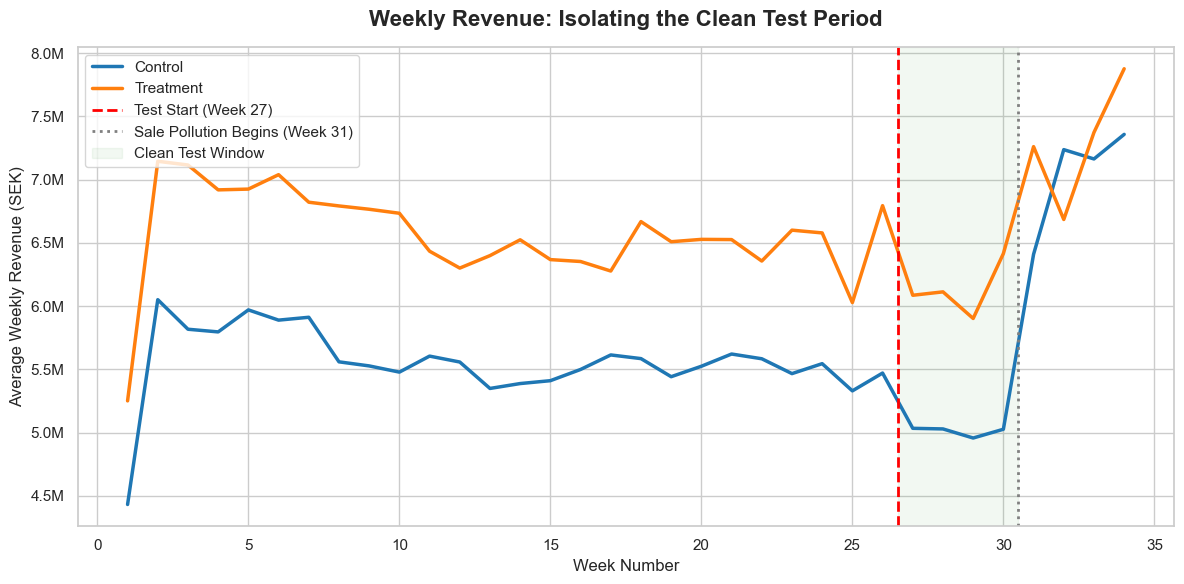

In [22]:
# Create the Plot using your 'weekly_rev' dataframe
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot the lines using your exact column names
sns.lineplot(data=weekly_rev, x='week', y='total_weekly_revenue', hue='group', 
             palette={'Treatment': '#ff7f0e', 'Control': '#1f77b4'}, linewidth=2.5)

# Add vertical lines for Test Start and End of Clean Period
plt.axvline(x=26.5, color='red', linestyle='--', linewidth=2, label='Test Start (Week 27)')
plt.axvline(x=30.5, color='gray', linestyle=':', linewidth=2, label='Sale Pollution Begins (Week 31)')

# Highlight the clean period background
plt.axvspan(26.5, 30.5, color='green', alpha=0.05, label='Clean Test Window')

# Formatting for the presentation
plt.title('Weekly Revenue: Isolating the Clean Test Period', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Week Number', fontsize=12)
plt.ylabel('Average Weekly Revenue (SEK)', fontsize=12)

# Format Y-axis to show millions cleanly (e.g., 5M, 6M)
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend(title='', loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## ROAS
- Calculating ROAS for the clean window of weeks 27-30, before the 'Mid Season Sale'

In [23]:
# 1. Filter Drive to Store spend in Treatment cities during clean weeks only
dts_spend_clean = spend[
    (spend['campaign'] == 'Drive to Store') &
    (spend['group'] == 'Treatment') &
    (spend['week'] >= 27) &
    (spend['week'] < 31)
]

# 2. Total and weekly average Drive to Store spend
# total_dts_spend = dts_spend_clean['spend_sek'].sum()
weekly_dts_spend = dts_spend_clean['spend_sek'].sum() / 4  # 4 clean weeks

# 3. Weekly incremental revenue from clean DiD
weekly_incremental_revenue = clean_lift  # ~104,686 SEK/week

# 4. ROAS = Incremental Revenue / Ad Spend
roas = weekly_incremental_revenue / weekly_dts_spend

print("--- Drive to Store ROAS (Clean Window, Weeks 27-30) ---")
print(f"Weekly Drive to Store Spend:         {weekly_dts_spend:,.0f} SEK")
print(f"Weekly Incremental Revenue (DiD):    {weekly_incremental_revenue:,.0f} SEK")
print(f"Implied ROAS:                        {roas:.2f}x")
print(f"\nInterpretation: For every 1 SEK spent on Drive to Store,")
print(f"the campaign generated ~{roas:.1f} SEK in incremental in-store revenue.")
print(f"\nNote: Based on only 4 weeks of data (p=0.678), this is directional only.")
print(f"Treat as a signal, not a confirmed result.")

--- Drive to Store ROAS (Clean Window, Weeks 27-30) ---
Weekly Drive to Store Spend:         143,838 SEK
Weekly Incremental Revenue (DiD):    104,686 SEK
Implied ROAS:                        0.73x

Interpretation: For every 1 SEK spent on Drive to Store,
the campaign generated ~0.7 SEK in incremental in-store revenue.

Note: Based on only 4 weeks of data (p=0.678), this is directional only.
Treat as a signal, not a confirmed result.


- the campaign shows a directional positive lift of ~104k SEK/week, but the implied ROAS of 0.73x is below breakeven and crucially, with p=0.678 on only 4 weeks of data, neither the lift nor the ROAS estimate is reliable enough to act on.
- Probably should run a clean test for more weeks, isolated from any promotions, to see if ROAS crosses 1.0x.

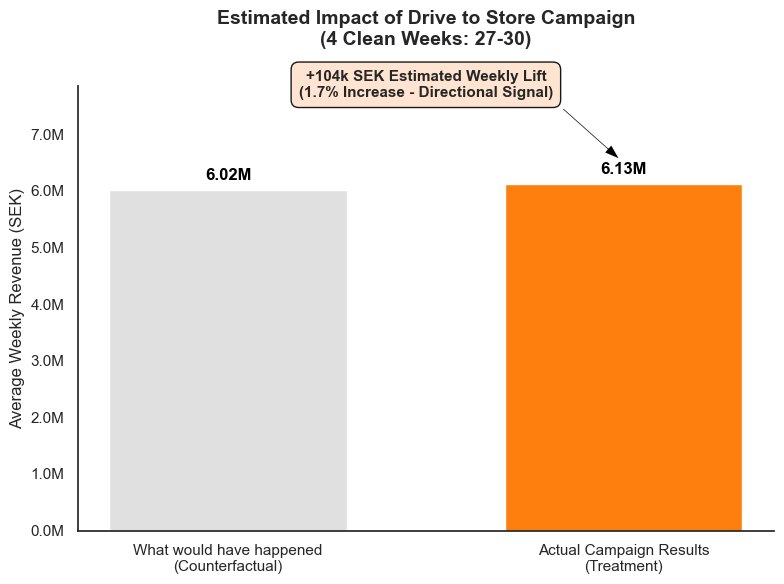

In [34]:
# 1. Calculate values
actual_treatment_revenue = clean_weekly_rev[(clean_weekly_rev['group']=='Treatment') & (clean_weekly_rev['period']=='Test')]['total_weekly_revenue'].mean()
#clean_lift = 104686 
counterfactual_revenue = actual_treatment_revenue - clean_lift
lift_percent = (clean_lift / counterfactual_revenue) * 100

# 2. Create the Plot
plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

categories = ['What would have happened\n(Counterfactual)', 'Actual Campaign Results\n(Treatment)']
values = [counterfactual_revenue, actual_treatment_revenue]

# Consistency: Treatment Orange for the results bar
bars = plt.bar(categories, values, color=['#e0e0e0', '#ff7f0e'], width=0.6)

plt.title('Estimated Impact of Drive to Store Campaign\n(4 Clean Weeks: 27-30)', fontsize=14, fontweight='bold', pad=30)
plt.ylabel('Average Weekly Revenue (SEK)', fontsize=12)

# 3. Data Labels: Positioned clearly on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f'{yval/1000000:.2f}M', 
             ha='center', va='bottom', color='black', fontweight='bold', fontsize=12)

# 4. Refined Annotation: Arrow pointing to the top of 6.13M, removed '*' 
plt.annotate(f'+104k SEK Estimated Weekly Lift\n({lift_percent:.1f}% Increase - Directional Signal)', 
             xy=(1, actual_treatment_revenue + (actual_treatment_revenue * 0.06)), # Pointing just above the label
             xytext=(0.5, actual_treatment_revenue * 1.25), # Moved higher to avoid crowding
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, ha='center', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.5", fc=(1.0, 0.89, 0.80, 1.0), ec="black", lw=1, alpha=0.9))

# 5. Final Formatting
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# Set Y-limit higher to accommodate the raised annotation box
plt.ylim(0, actual_treatment_revenue * 1.28) 

sns.despine()
plt.tight_layout()

plt.show()